In [1]:
import numpy as np
from PIL import Image, ImageOps
def trim_whitespace(path,padding=0):
    # Code from
    # https://gist.github.com/thomastweets/c7680e41ed88452d3c63401bb35116ed
    padding = np.array([-1*padding, -1*padding, padding, padding])
    image=Image.open(path)
    image.load()
    imageSize = image.size
    # remove alpha channel
    invert_im = image.convert("RGB")
    # invert image (so that white is 0)
    invert_im = ImageOps.invert(invert_im)
    imageBox = invert_im.getbbox()
    imageBox = tuple(np.asarray(imageBox)+padding)
    cropped=image.crop(imageBox)
    print("Size:", imageSize, "New Size:", imageBox)
    cropped.save(path)

def save_trim_push(path,name,padding=0,trim=True,subfolder="figures",dpi=None):
    # By default I save all my figures in a subfolder called "figures".
    # Make sure this subfolder exists before you exectue this function.
    full_path = os.path.join(path,subfolder,name)
    if dpi is None:
        dpi = plt.gcf().get_dpi()
    plt.savefig(full_path,dpi=dpi)
    if trim:
        trim_whitespace(full_path,padding)
    push2overleaf(path,name)
    return

import os
def push2overleaf(path, comment):
    # get current pwd
    tmp_pwd = os.getcwd()
    # change pwd to git repo
    os.chdir(path)
    # do git commands
    os.system("git pull")
    os.system("git add .")
    os.system('git commit -m "' + comment + '"')
    os.system("git push")
    # change pwd back
    os.chdir(tmp_pwd)
    return

git_path = "/home/mgotsmy/overleaf/688f5daf4e30e6d98498e7b8/"

# Step 1: Symbolic Regression

In [2]:
import os
os.environ['JAX_PLATFORMS'] = 'cpu'
import sys
sys.path.append("/mnt/y/code/250513_metabolic_process_models")
import jax 
import jax.numpy as jnp
import equinox as eqx
import importlib
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
import numpy as np
import sympy as sp
import pysr

import MPMs.MPM_functions_07 as MF
import MPMs.DATA_functions_01 as DF
import MPMs.UTIL_functions_01 as UF
importlib.reload(UF)
importlib.reload(DF)
importlib.reload(MF);

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [3]:
model_path = "/mnt/y/code/250513_metabolic_process_models/prol_fba_data/02_run_SR_on_FBA.py"
MM = UF.import_module_from_path(model_path)
importlib.reload(MM)

COL_inp, COL_out = MM.get_columns_inp_out()


# --- LOAD DATA --- #
X, Y = MM.get_FBA_data(COL_inp, COL_out)

# --- GET SCALERS --- #
SCLs = MM.get_scalers(COL_inp, COL_out)

# --- PREPROCESS DATA --- #
train_, valid_ = MM.split_scale(X,Y,SCLs)
print(train_[0].shape, train_[1].shape, valid_[0].shape, valid_[1].shape)

(9000, 4) (9000, 8) (1000, 4) (1000, 8)


In [4]:
model = pysr.PySRRegressor.from_file(run_directory=f"sr_models/run_SR_on_FBA_03")

x_data, y_data = valid_
y_pred = model.predict(x_data)
Y_data = SCLs[1].unscale(y_data)
Y_pred = SCLs[1].unscale(y_pred)

Attempting to load model from sr_models/run_SR_on_FBA_03/checkpoint.pkl...


Lowest 5% of the data
name                              tmp_r2   tmp_mae
EX_glyc_e_i                       1.0000    0.0000
protein_synthesis                 1.0000    0.0000
BIOMASS_Ec_iJO1366_core_53p95M    1.0000    0.0000
ATPM                              1.0000    0.0004
EX_co2_e_o                        0.9952    0.0263
EX_nh4_e_i                        0.9996    0.0022
EX_o2_e_i                         1.0000    0.0006
EX_so4_e_i                        0.9866    0.0001


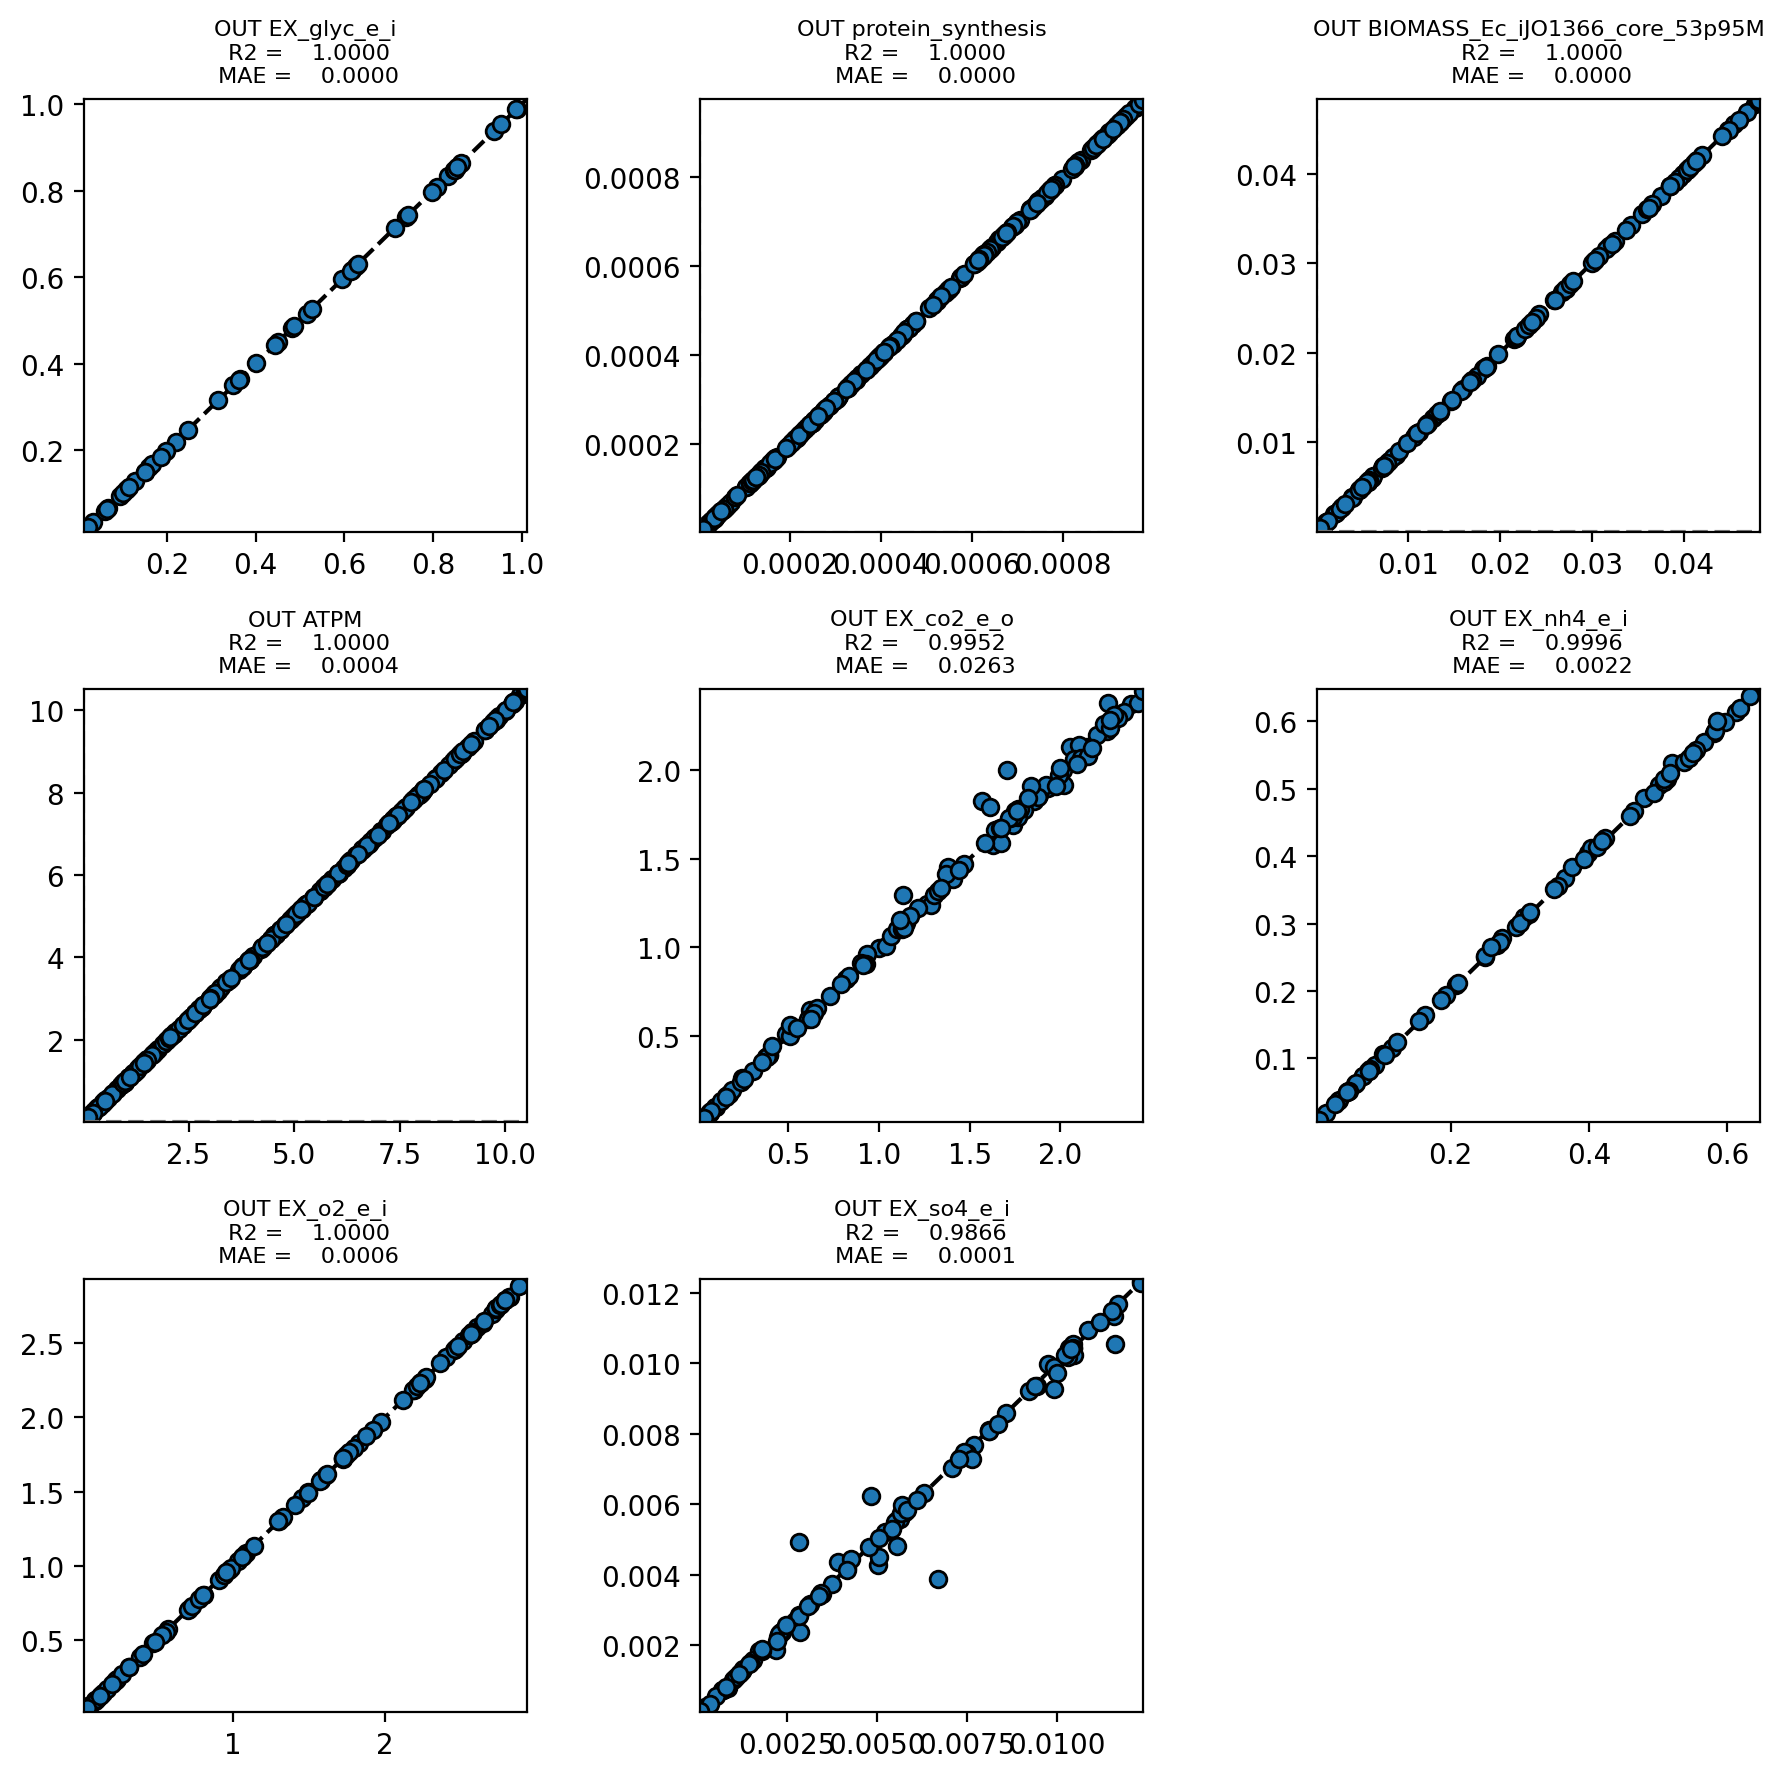

In [5]:
lowest_n_percent = 100
lowest_n_percent = 5
n = 0
n_cols = 3
# COL_out = ['BIOMASS_Ec_iJO1366_core_53p95M']
n_rows = (len(COL_out))//n_cols+1
plt.figure(dpi=200,figsize=(n_cols*3,n_rows*3))

print(f"Lowest {lowest_n_percent}% of the data")
print(f"{'name':30} {'tmp_r2':>9} {'tmp_mae':>9}")
for i, name in enumerate(COL_out):
    # find the lowest_n_percent of the data
    _max = Y_data[:,i].max()
    _min = Y_data[:,i].min()
    _range = _max - _min
    _new_max = _min + (_range * (lowest_n_percent / 100))
    _new_max_mask = Y_pred[:,i] <= _new_max


    n += 1
    ax = plt.subplot(n_rows,n_cols,n)
    tmp_r2 = UF.R2(Y_data[_new_max_mask,i],Y_pred[_new_max_mask,i])
    tmp_mae= UF.MAE(Y_data[_new_max_mask,i],Y_pred[_new_max_mask,i])
    print(f"{name:30} {tmp_r2:9.4f} {tmp_mae:9.4f}")
    plt.title(f"OUT {name}\n R2 = {tmp_r2:9.4f}\n MAE = {tmp_mae:9.4f}",fontsize=8)
    plt.scatter(Y_data[_new_max_mask,i],Y_pred[_new_max_mask,i],edgecolor="k")
    UF.diag(ax)
    ax.axhline(0,color="grey",linestyle="--")
    ax.axvline(0,color="grey",linestyle="--")
    ax.set_xlim(_min,_new_max)
    ax.set_ylim(_min,_new_max)
plt.tight_layout()
plt.show()

In [6]:
for i, flux in enumerate(COL_out):
    eq = model.sympy()[i].simplify()
    print(f"{flux[:10]:10} = "+sp.pycode(eq).replace("*"," * ").replace("/", " / "))

EX_glyc_e_ = qG
protein_sy = 3.8841403 * nr_P * qG / (0.979605783122333 * nr_M + 0.92360526 * nr_P + 2.29124042386367 * nr_X)
BIOMASS_Ec = nr_X * qG / (0.218552666394428 * nr_M + 0.20587991267762 * nr_P + 0.51121837 * nr_X)
ATPM       = 1.702509 * nr_M * qG / (0.4275212 * nr_M + 0.402968465731569 * nr_P + nr_X)
EX_co2_e_o = qG * (1.21761705930026 * nr_M + 0.272176769568876 * nr_P + 0.4747948 * nr_X) / (0.45833918 * nr_M + 0.57325137 * nr_P + nr_X)
EX_nh4_e_i = 1.3974786 * qG * (nr_P + 2.12016119585572 * nr_X) / (nr_M + nr_P + 2.27038217433956 * nr_X + 0.00997540000000008 * qG - 0.0142505981548877)
EX_o2_e_i  = qG * (1.84548880325013 * nr_M + 0.366223510252728 * nr_P + 1.24445843784701 * nr_X) / (0.830402014223126 * nr_M + 0.774971351130509 * nr_P + 1.93852720970504 * nr_X)
EX_so4_e_i = -qG * (nr_X / (-0.24718794 * nr_M - nr_X / (nr_X / (0.24471837 * nr_P + 0.601120777667546 * nr_X) + 0.15294719)) - 0.056461122)


Here we notice the general form of the equations is:

$$
q_i = q_G \frac{\sum_j Y_{ij}n_j}{\sum_j W_{ij}n_j}
$$

for $i \in \{\text{X},\,\text{P},\,\text{M},\,\text{CO}_{2},\,\text{O}_{2},\,\text{NH}_{4},\,\text{SO}_{4}\}$ and $j \in \{\text{X},\,\text{P},\,\text{M}\}$. We use this structure to fit the model with scipy.

# Step 2: Parameter Fitting

In [10]:
x_data, y_data = train_

In [24]:
import scipy

def get_qN_multi(x_data,denominator,Y):
    numerator = get_denominator(x_data,Y[0],Y[1],Y[2])
    qN = x_data[:,0]*numerator/denominator
    return qN

def get_qN(x_data,denominator,yN,N):
    qN = x_data[:,0]*x_data[:,N]*yN/denominator
    return qN

def get_denominator(x_data,y1,y2,y3):
    return x_data[:,1] * y1 + x_data[:,2] * y2 + x_data[:,3] * y3

def get_L_qN(qN_pred,qN_data):
    return np.mean(np.abs(qN_pred - qN_data))

def fun(theta,*args):
    global i
    i += 1

    x_data, y_data = args
    y1, y2, y3 = theta[:3]
    yX, yP, yM = theta[3:6]
    Y1 = theta[6:9]
    Y2 = theta[9:12]
    Y3 = theta[12:15]
    Y4 = theta[15:18]
    D1 = theta[18:21]
    D2 = theta[21:24]
    D3 = theta[24:27]
    D4 = theta[27:30]


    denominator = get_denominator(x_data, y1,y2,y3)

    qX_pred = get_qN(x_data, denominator, yX, 1)
    L_qX = get_L_qN(qX_pred,y_data[:,2])#/SCLs[1].avg[2]

    qP_pred = get_qN(x_data, denominator, yP, 2)
    L_qP = get_L_qN(qP_pred,y_data[:,1])#/SCLs[1].avg[1]

    qM_pred = get_qN(x_data, denominator, yM, 3)
    L_qM = get_L_qN(qM_pred,y_data[:,3])#/SCLs[1].avg[3]


    q1_pred = get_qN_multi(x_data, get_denominator(x_data,*D1), Y1)
    L_q1 = get_L_qN(q1_pred,y_data[:,4])#/SCLs[1].avg[4]

    q2_pred = get_qN_multi(x_data, get_denominator(x_data,*D2), Y2)
    L_q2 = get_L_qN(q2_pred,y_data[:,5])#/SCLs[1].avg[5]

    q3_pred = get_qN_multi(x_data, get_denominator(x_data,*D3), Y3)
    L_q3 = get_L_qN(q3_pred,y_data[:,6])#/SCLs[1].avg[6]

    q4_pred = get_qN_multi(x_data, get_denominator(x_data,*D4), Y4)
    L_q4 = get_L_qN(q4_pred,y_data[:,7])#/SCLs[1].avg[7]
    
    if i%100==0 or i == 1:
        # print(i, L_qX, L_qP, L_qM, L_q1, L_q2, L_q3, L_q4)
        print(f"{i:5} | {L_qX:6.3e} | {L_qP:6.3e} | {L_qM:6.3e} | {L_q1:6.3e} | {L_q2:6.3e} | {L_q3:6.3e} | {L_q4:6.3e}")
    return L_qX + L_qP + L_qM + L_q1 + L_q2 + L_q3 + L_q4
    # return L_qX+L_qP+L_qM
    # return L_q4

i = 0
args = (x_data,y_data)
theta0 = np.ones(30)
theta0[0:6] = np.array([0.73928757, 0.29803819, 0.31613452, 1.44661521, 1.25335457, 1.2589659 ])
theta0[6:9] = np.array([0.71038968, 0.14703757, 1.44567422])
theta0[18:21] = np.array([1.29887228, 0.52364375, 0.55542952])
theta0[9:12] = np.array([ 3.26202793e+00,  1.43458480e+00, -1.66355319e-07])
theta0[21:24] = np.array([2.51322911, 1.01319171, 1.07470983])
theta0[12:15] = np.array([1.16486152, 0.34997064, 1.7309298 ])
theta0[24:27] = np.array([1.81837903, 0.73307251, 0.77757829])
theta0[15:18] = np.array([3.54709860e+00, 1.40307899e-01, 9.48840272e-05])
theta0[27:30] = np.array([1.89621567, 0.76348943, 0.81073861])

_ = scipy.optimize.minimize(fun, x0=theta0, args=args, method='Nelder-Mead',options={"fatol":1e-8,"xatol":1e-8})
# _ = scipy.optimize.minimize(fun, x0=np.ones(30), args=args, method='COBYLA',options={"tol":1e-16})#,options={"fatol":1e-16,"xatol":1e-16})
print("done")
print(_.message)

    1 | 7.955e-05 | 1.259e-05 | 4.583e-05 | 9.050e-05 | 5.700e-05 | 6.968e-05 | 6.082e-05
  100 | 1.201e-04 | 1.246e-02 | 1.918e-04 | 9.016e-04 | 1.116e-03 | 6.838e-04 | 1.305e-03
  200 | 2.172e-04 | 8.415e-05 | 2.754e-03 | 7.049e-04 | 3.054e-04 | 2.758e-04 | 2.305e-04
  300 | 9.998e-05 | 5.786e-05 | 1.212e-04 | 1.724e-03 | 2.479e-04 | 2.836e-04 | 1.953e-04
  400 | 9.365e-05 | 6.971e-05 | 8.990e-05 | 2.000e-04 | 1.004e-04 | 8.773e-05 | 1.529e-04
  500 | 9.010e-05 | 1.514e-04 | 4.862e-05 | 1.358e-04 | 6.892e-05 | 7.867e-05 | 9.074e-05
  600 | 7.969e-05 | 2.055e-05 | 4.735e-05 | 9.329e-05 | 6.309e-05 | 7.316e-05 | 6.426e-05
  700 | 7.832e-05 | 1.700e-05 | 4.737e-05 | 9.393e-05 | 6.009e-05 | 7.085e-05 | 6.092e-05
  800 | 7.916e-05 | 1.530e-05 | 4.630e-05 | 9.201e-05 | 5.760e-05 | 7.138e-05 | 6.154e-05
  900 | 7.917e-05 | 1.419e-05 | 4.623e-05 | 9.088e-05 | 5.720e-05 | 7.006e-05 | 6.088e-05
 1000 | 7.951e-05 | 1.273e-05 | 4.588e-05 | 9.065e-05 | 5.709e-05 | 6.977e-05 | 6.084e-05
 1100 | 7.

Lowest 1% of the data
name                              tmp_r2   tmp_mae
BIOMASS                          1.00000   0.00000
protein_synthesis                1.00000   0.00001
ATPM                             1.00000   0.00000
EX_co2_e_o                       1.00000   0.00000
EX_nh4_e_i                       1.00000   0.00000
EX_o2_e_i                        1.00000   0.00000
EX_so4_e_i                       1.00000   0.00000


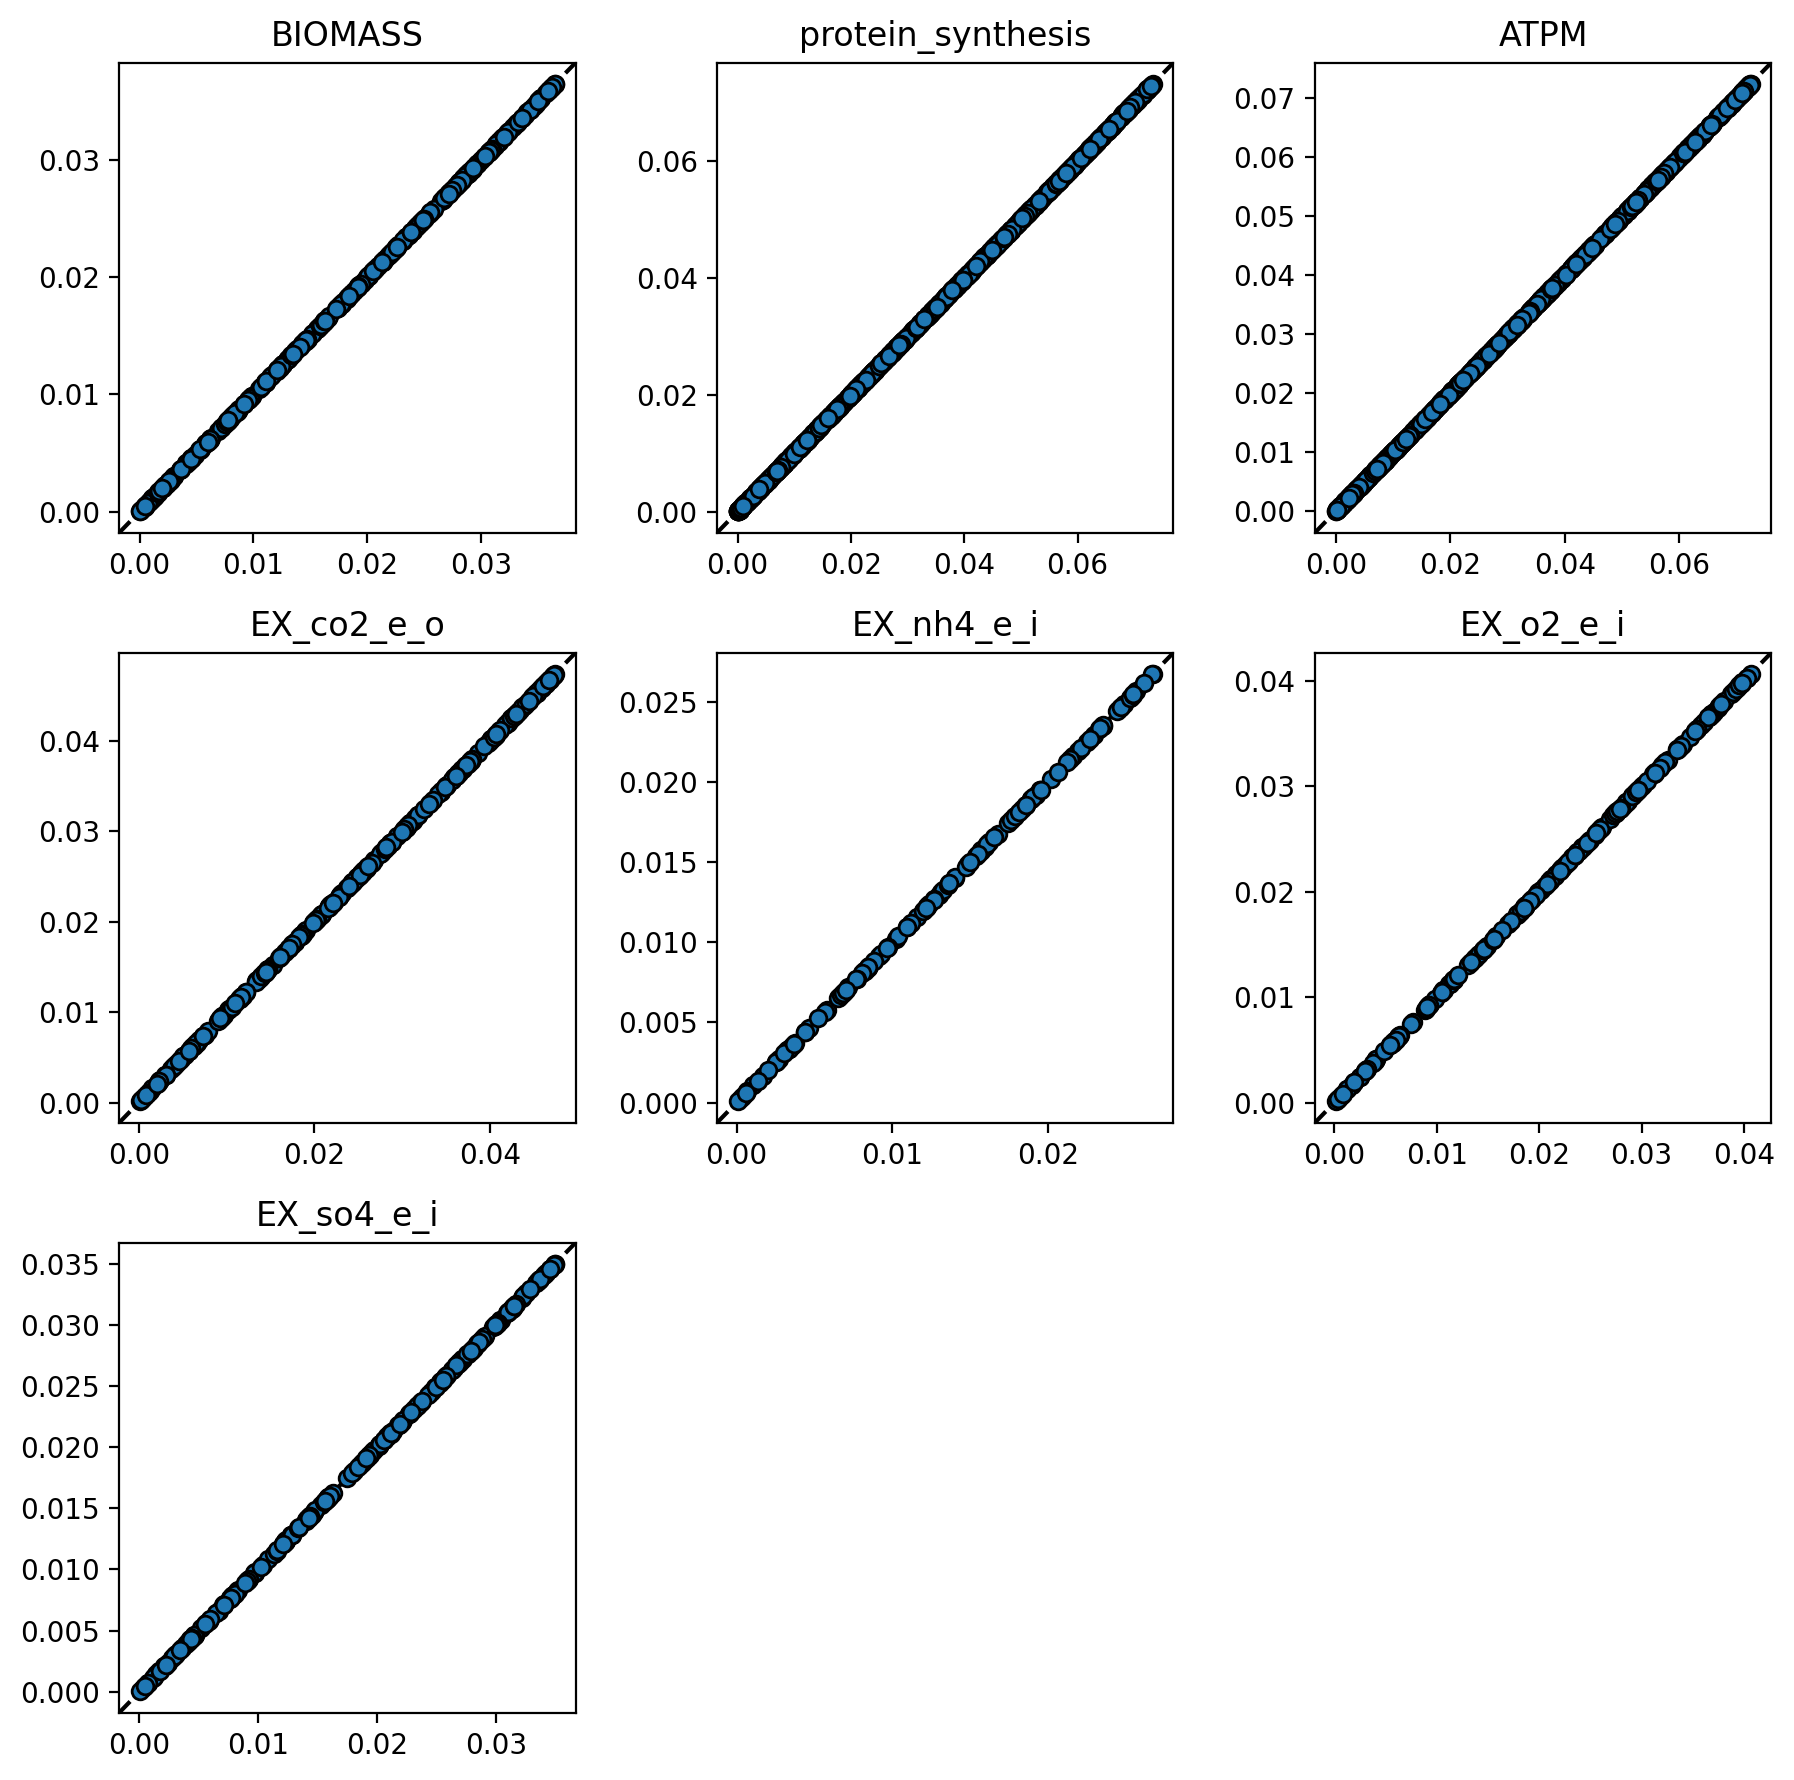

In [25]:
x_data, y_data = args
theta = _.x

y1, y2, y3 = theta[:3]
yX, yP, yM = theta[3:6]
Y1 = theta[6:9]
Y2 = theta[9:12]
Y3 = theta[12:15]
Y4 = theta[15:18]
D1 = theta[18:21]
D2 = theta[21:24]
D3 = theta[24:27]
D4 = theta[27:30]


denominator = get_denominator(x_data, y1,y2,y3)
lowest_n_percent = 100
lowest_n_percent = 1
print(f"Lowest {lowest_n_percent}% of the data")
print(f"{'name':30} {'tmp_r2':>9} {'tmp_mae':>9}")

n_cols = 3
n_rows = (len(COL_out))//n_cols+1
plt.figure(dpi=200,figsize=(n_cols*3,n_rows*3))

for LOC_inp, LOC_out in zip([1,2,3],[2,1,3]):
    name = COL_out[LOC_out].replace("_Ec_iJO1366_core_53p95M","")
    ax = plt.subplot(n_rows,n_cols,LOC_inp)
    ax.set_title(name)
    
    _max = y_data[:,LOC_out].max()
    _min = y_data[:,LOC_out].min()
    _range = _max - _min
    _new_max = _min + (_range * (lowest_n_percent / 100))
    _new_max_mask = y_data[:,LOC_out] <= _new_max

    
    
    q_pred = get_qN(x_data, denominator, theta[LOC_inp+2], LOC_inp)
    L = get_L_qN(q_pred[_new_max_mask],y_data[_new_max_mask,LOC_out])

    tmp_r2 = UF.R2( y_data[_new_max_mask,LOC_out],q_pred[_new_max_mask])
    tmp_mae= UF.MAE(y_data[_new_max_mask,LOC_out],q_pred[_new_max_mask])
    print(f"{name:30} {tmp_r2:9.5f} {tmp_mae:9.5f}")


    plt.scatter( q_pred[_new_max_mask],y_data[_new_max_mask,LOC_out],edgecolors="k")
    UF.diag(ax)

DD = [D1,D2,D3,D4]
YY = [Y1,Y2,Y3,Y4]
for j, LOC_out in enumerate([4,5,6,7]):
    name = COL_out[LOC_out].replace("_Ec_iJO1366_core_53p95M","")
    ax = plt.subplot(n_rows,n_cols,LOC_out)
    ax.set_title(name)

    _max = y_data[:,LOC_out].max()
    _min = y_data[:,LOC_out].min()
    _range = _max - _min
    _new_max = _min + (_range * (lowest_n_percent / 100))
    _new_max_mask = y_data[:,LOC_out] <= _new_max
    
    q_pred = get_qN_multi(x_data, get_denominator(x_data,*DD[j]), YY[j])
    L = get_L_qN(q_pred[_new_max_mask],y_data[_new_max_mask,LOC_out])

    tmp_r2 = UF.R2( y_data[_new_max_mask,LOC_out],q_pred[_new_max_mask])
    tmp_mae= UF.MAE(y_data[_new_max_mask,LOC_out],q_pred[_new_max_mask])
    print(f"{name:30} {tmp_r2:9.5f} {tmp_mae:9.5f}")


    ax.scatter( q_pred[_new_max_mask],y_data[_new_max_mask,LOC_out],edgecolors="k")
    UF.diag(ax)

plt.tight_layout()
plt.show()

In [26]:
x_data, y_data = args
theta = _.x

y1, y2, y3 = theta[:3]
yX, yP, yM = theta[3:6]
Y1 = theta[6:9]
Y2 = theta[9:12]
Y3 = theta[12:15]
Y4 = theta[15:18]
D1 = theta[18:21]
D2 = theta[21:24]
D3 = theta[24:27]
D4 = theta[27:30]

flux_names = ["qG","qX","qP","qM","qCO2","qNH4","qO2","qSO4"]
denominator = get_denominator(x_data, y1,y2,y3)
for LOC_inp, LOC_out in zip([1,2,3],[2,1,3]):
    name = COL_out[LOC_out].replace("_Ec_iJO1366_core_53p95M","")
    
    q_pred = get_qN(x_data, denominator, theta[LOC_inp+2], LOC_inp)

    dem_str = ""
    yy = [y1,y2,y3]
    for j in [1,2,3]:
        dem_str += f"{yy[j-1]}*{COL_inp[j]} + "
    dem_str = dem_str[:-3]
    print(f"{flux_names[LOC_inp]} = qG * {theta[LOC_inp+2]}*{COL_inp[LOC_inp]} /({dem_str}) ".replace("nr","n"))

DD = [D1,D2,D3,D4]
YY = [Y1,Y2,Y3,Y4]
for j, LOC_out in enumerate([4,5,6,7]):
    
    q_pred = get_qN_multi(x_data, get_denominator(x_data,*DD[j]), YY[j])
    L = get_L_qN(q_pred[_new_max_mask],y_data[_new_max_mask,LOC_out])

    dem_str = ""
    num_str = ""
    for k in [1,2,3]:
        dem_str += f"{DD[j][k-1]}*{COL_inp[k]} + "
        num_str += f"{YY[j][k-1]}*{COL_inp[k]} + "
    dem_str = dem_str[:-3]
    num_str = num_str[:-3]
    print(f"{flux_names[LOC_out]} = qG * ({num_str}) /({dem_str}) ".replace("nr","n"))


qX = qG * 1.4466152118353457*n_X /(0.7392875709919655*n_X + 0.2980381900321115*n_P + 0.31613452043825985*n_M) 
qP = qG * 1.2533545707500648*n_P /(0.7392875709919655*n_X + 0.2980381900321115*n_P + 0.31613452043825985*n_M) 
qM = qG * 1.2589659007754128*n_M /(0.7392875709919655*n_X + 0.2980381900321115*n_P + 0.31613452043825985*n_M) 
qCO2 = qG * (0.7103896793658289*n_X + 0.14703757632448644*n_P + 1.4456742282955575*n_M) /(1.298872281676593*n_X + 0.5236437595294949*n_P + 0.5554295204483248*n_M) 
qNH4 = qG * (3.262027935153786*n_X + 1.4345848108836146*n_P + -1.6645366599114816e-07*n_M) /(2.5132291325136933*n_X + 1.01319170879044*n_P + 1.0747098312334038*n_M) 
qO2 = qG * (1.1648615214015603*n_X + 0.34997064629049257*n_P + 1.7309298084472662*n_M) /(1.8183790356051481*n_X + 0.7330725210391213*n_P + 0.7775782907021771*n_M) 
qSO4 = qG * (3.547098615145487*n_X + 0.1403078990559169*n_P + 9.506688895607793e-05*n_M) /(1.8962156727604698*n_X + 0.7634894500553386*n_P + 0.8107386190016588*n_M) 


## Figure for Manuscript

In [7]:
def general_predictor(x_data):
    qG = x_data[:,0]
    n_X = x_data[:,1]
    n_P = x_data[:,2]
    n_M = x_data[:,3]
    qX = qG * 1.4466152118353457*n_X /(0.7392875709919655*n_X + 0.2980381900321115*n_P + 0.31613452043825985*n_M) 
    qP = qG * 1.2533545707500648*n_P /(0.7392875709919655*n_X + 0.2980381900321115*n_P + 0.31613452043825985*n_M) 
    qM = qG * 1.2589659007754128*n_M /(0.7392875709919655*n_X + 0.2980381900321115*n_P + 0.31613452043825985*n_M) 
    qCO2 = qG * (0.7103896793658289*n_X + 0.14703757632448644*n_P + 1.4456742282955575*n_M) /(1.298872281676593*n_X + 0.5236437595294949*n_P + 0.5554295204483248*n_M) 
    qNH4 = qG * (3.262027935153786*n_X + 1.4345848108836146*n_P + -1.6645366599114816e-07*n_M) /(2.5132291325136933*n_X + 1.01319170879044*n_P + 1.0747098312334038*n_M) 
    qO2 = qG * (1.1648615214015603*n_X + 0.34997064629049257*n_P + 1.7309298084472662*n_M) /(1.8183790356051481*n_X + 0.7330725210391213*n_P + 0.7775782907021771*n_M) 
    qSO4 = qG * (3.547098615145487*n_X + 0.1403078990559169*n_P + 9.506688895607793e-05*n_M) /(1.8962156727604698*n_X + 0.7634894500553386*n_P + 0.8107386190016588*n_M)
    return jnp.stack([qG,qP,qX,qM,qCO2,qNH4,qO2,qSO4],axis=1)

In [8]:
# validation data set

x_data, y_data = valid_
y_pred = general_predictor(x_data)

Lowest 100% of the data
name                              tmp_r2   tmp_mae
protein_synthesis                 1.0000    0.0000
BIOMASS_Ec_iJO1366_core_53p95M    1.0000    0.0001
ATPM                              1.0000    0.0001
EX_so4_e_i                        1.0000    0.0001
Size: (2100, 1800) New Size: (np.int64(151), np.int64(60), np.int64(1983), np.int64(1667))


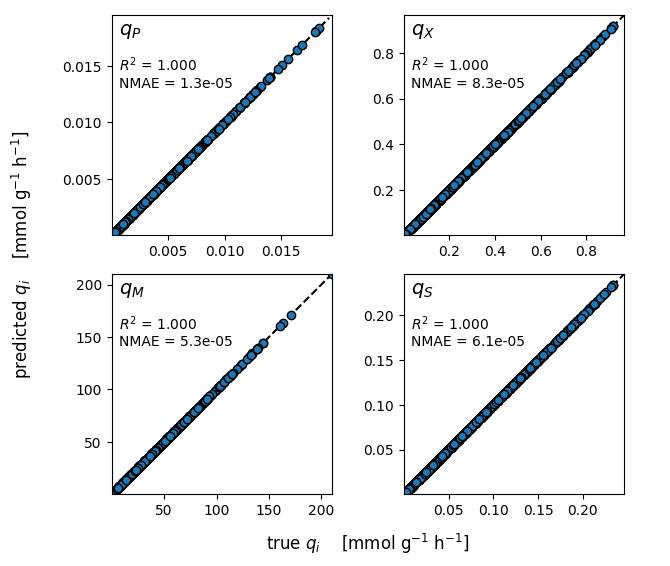

From https://git.overleaf.com/688f5daf4e30e6d98498e7b8
   8d62237..589ca2c  master     -> origin/master
remote: Updating references: 100% (1/1)           
To https://git.overleaf.com/688f5daf4e30e6d98498e7b8
   589ca2c..5ed3db5  master -> master


Updating 8d62237..589ca2c
Fast-forward
 01_packages.tex                |  10 +++-
 02_macros.tex                  |   8 +++
 05_methods.tex                 | 110 ++++++++++++++++++++++++-----------------
 06_results.tex                 |  68 ++++++++++++++++++-------
 07_discussion.tex              |  46 +++++++++++------
 08_conclusion.tex              |   2 +-
 09_supplements.tex             |  79 +++++++++++++++--------------
 cas-refs.bib                   |  26 ++++++++++
 figures/training_flowsheet.tex |  29 ++++++-----
 main.tex                       |   1 +
 10 files changed, 247 insertions(+), 132 deletions(-)
[master 5ed3db5] surrogate_fba_performance.png
 1 file changed, 0 insertions(+), 0 deletions(-)


In [64]:
importlib.reload(UF)

Y_data = y_data
Y_pred = y_pred

Y_data = SCLs[1].unscale(y_data)
Y_pred = SCLs[1].unscale(y_pred)

lowest_n_percent = 100 # plot all data
n = 0
n_cols = 2
# COL_out = ['BIOMASS_Ec_iJO1366_core_53p95M']
n_rows = 2
fig = plt.figure(dpi=100,figsize=(7,6))
# Create invisible subplot.
ax0 = fig.add_subplot(111, frame_on=False)
ax0.tick_params(labelcolor="none", top=False, bottom=False, left=False, right=False)
ax0.grid(False)
# Set the centered xlabel on invisible subplot.
ax0.set_xlabel(r'true $q_i\quad$ [mmol g$^{-1}$ h$^{-1}]$', labelpad=10, fontsize=12)
ax0.set_ylabel(r'predicted $q_i\quad$ [mmol g$^{-1}$ h$^{-1}]$', labelpad=15, fontsize=12)
print(f"Lowest {lowest_n_percent}% of the data")
print(f"{'name':30} {'tmp_r2':>9} {'tmp_mae':>9}")
relevant_indices = [1,2,3,7]
fancynames = [r"$q_P$",r"$q_X$",r"$q_M$",r"$q_S$"]

axes = []
for i, name, fancyname in zip(relevant_indices,COL_out[relevant_indices],fancynames):
# for i, name in enumerate(COL_out):
    # print(i,name)
    # find the lowest_n_percent of the data
    _max = Y_data[:,i].max()
    _min = Y_data[:,i].min()
    _range = _max - _min
    _new_max = _min + (_range * (lowest_n_percent / 100))
    _new_max_mask = Y_pred[:,i] <= _new_max


    n += 1
    ax = plt.subplot(n_rows,n_cols,n,box_aspect=1)
    tmp_r2 = UF.R2(Y_data[_new_max_mask,i],Y_pred[_new_max_mask,i])
    tmp_mae= UF.NMAE(Y_data[_new_max_mask,i],Y_pred[_new_max_mask,i])
    print(f"{name:30} {tmp_r2:9.4f} {tmp_mae:9.4f}")
    # plt.title(f"{fancyname}")
    text = "\n\n"+rf"$R^2$ = {tmp_r2:5.3f}"+"\n"+rf"NMAE = {tmp_mae:5.1e}"
    trans = mtransforms.ScaledTranslation(5/72, -5/72, fig.dpi_scale_trans)
    ax.text(0.0, 1.0, text, transform=ax.transAxes + trans,
    fontsize=10, verticalalignment='top', fontfamily='sans',
    bbox=dict(facecolor='none', edgecolor='none', pad=3.0))


    plt.scatter(Y_data[_new_max_mask,i],Y_pred[_new_max_mask,i],edgecolor="k")
    UF.diag(ax)
    # ax.axhline(0,color="grey",linestyle="--")
    # ax.axvline(0,color="grey",linestyle="--")
    ax.set_xlim(_min,_new_max)
    ax.set_ylim(_min,_new_max)
    axes.append(ax)

import matplotlib.transforms as mtransforms
for name, ax in zip(fancynames,axes):
    trans = mtransforms.ScaledTranslation(5/72, -5/72, fig.dpi_scale_trans)
    ax.text(0.0, 1.0, name, transform=ax.transAxes + trans,
    fontsize=14, verticalalignment='top', fontfamily='sans',
    bbox=dict(facecolor='none', edgecolor='none', pad=3.0))
plt.tight_layout()

save_trim_push(git_path,"surrogate_fba_performance.png",dpi=300)
plt.show()

In [15]:
i = 7
print(SCLs[1].avg[i], SCLs[1].col[ i])

0.07781231 EX_so4_e_i


In [45]:
# Scaling of the values
scl = [
    [1],
    [0.29502080/10 ],
    [0.00340511/10 ],
    [33.8993760/10 ],
    [0.07781231/10 ],
]
scl = np.array(scl).flatten()

In [46]:
# parameters
arr = np.array([
    [0.7392875709919655, 0.2980381900321115, 0.3161345204382598, 0.7392875709919655, 0.2980381900321115, 0.3161345204382598],
    [1.4466152118353457, 0.0000000000000000, 0.0000000000000000, 0.7392875709919655, 0.2980381900321115, 0.3161345204382598],
    [0.0000000000000000, 1.2533545707500648, 0.0000000000000000, 0.7392875709919655, 0.2980381900321115, 0.3161345204382598],
    [0.0000000000000000, 0.0000000000000000, 1.2589659007754128, 0.7392875709919655, 0.2980381900321115, 0.3161345204382598],
    [3.5470986151454870, 0.1403078990559169, 0.0000950668889561, 1.8962156727604698, 0.7634894500553386, 0.8107386190016588],
    ])

In [47]:
sclarr = np.zeros_like(arr)

for i in range(arr.shape[0]):
    sclarr[i,:3] = arr[i,:3]*scl[i]
    sclarr[i,3:] = arr[i,3:]
    # break

In [57]:
import pandas as pd
tab = pd.DataFrame(sclarr,columns=['$Y_X$','$Y_P$','$Y_M$','$W_X$','$W_P$','$W_M$',],index=['$q_G$','$q_X$','$q_P$','$q_M$','$q_S$',])
print(tab.to_latex(float_format="%.4f"))

\begin{tabular}{lrrrrrr}
\toprule
 & $Y_X$ & $Y_P$ & $Y_M$ & $W_X$ & $W_P$ & $W_M$ \\
\midrule
$q_G$ & 0.7393 & 0.2980 & 0.3161 & 0.7393 & 0.2980 & 0.3161 \\
$q_X$ & 0.0427 & 0.0000 & 0.0000 & 0.7393 & 0.2980 & 0.3161 \\
$q_P$ & 0.0000 & 0.0004 & 0.0000 & 0.7393 & 0.2980 & 0.3161 \\
$q_M$ & 0.0000 & 0.0000 & 4.2678 & 0.7393 & 0.2980 & 0.3161 \\
$q_S$ & 0.0276 & 0.0011 & 0.0000 & 1.8962 & 0.7635 & 0.8107 \\
\bottomrule
\end{tabular}

